# MuTap vs. WebRTC AEC3 and Speex MDF — on the ITU battery

The [ITU compliance notebook](itu_compliance.ipynb) proves MuTap's echo
canceller against the in-force ITU-T automotive/hands-free requirements.
This companion runs the **same scenarios, signals, paths and meters**
(`tests/support/itu_chain.h` — P.501 CSS, the image-source car cabin and
studio, the dBm0 ERL reader) through **all three cancellers** so you can
see how WebRTC AEC3 and Speex MDF fare on the same masks.

Every subject is a black box: far-end + microphone in, cleaned send out
([`tools/notebook/itu_compare_dump.cpp`](../tools/notebook/itu_compare_dump.cpp)).
Full methodology, subjects, and the fairness caveats — float32 vs
float64, AEC3 running echo-canceller-only, echo within the filter's
modelling capacity, why raw ERLE is MuTap's axis and not AEC3's — are in
[`docs/aec-comparison.md`](../docs/aec-comparison.md). The certified
compliance notebook stays MuTap-only and remains the CI-gated authority;
this is the comparison view.

In [1]:
import json, pathlib
import numpy as np
import matplotlib.pyplot as plt

here = pathlib.Path.cwd()
root = here.parent if here.name == 'notebooks' else here
D = json.load(open(root / 'bench' / 'compare' / 'results' / 'itu_comparison.json'))
SUBJECTS = D['subjects']
COL = {'mutap': '#1f77b4', 'webrtc': '#d62728', 'speex': '#2ca02c'}
LBL = {'mutap': 'MuTap', 'webrtc': 'WebRTC AEC3', 'speex': 'Speex MDF'}
print('subjects:', SUBJECTS)

def trace_xy(tr):
    v = np.array(tr['v'], float)
    t = tr['t0'] + tr['dt'] * np.arange(len(v))
    return t, v

subjects: ['mutap', 'webrtc', 'speex']


## 1. Initial convergence, quiet (§11.11.4)

ERL against time from a cold start, cabin path, P.501 CSS at −16 dBm0.
The requirement is ≥ 40 dB by 1200 ms, held; MuTap's margin target is
≥ 40 dB by **600 ms**. The dashed line is the 40 dB requirement.

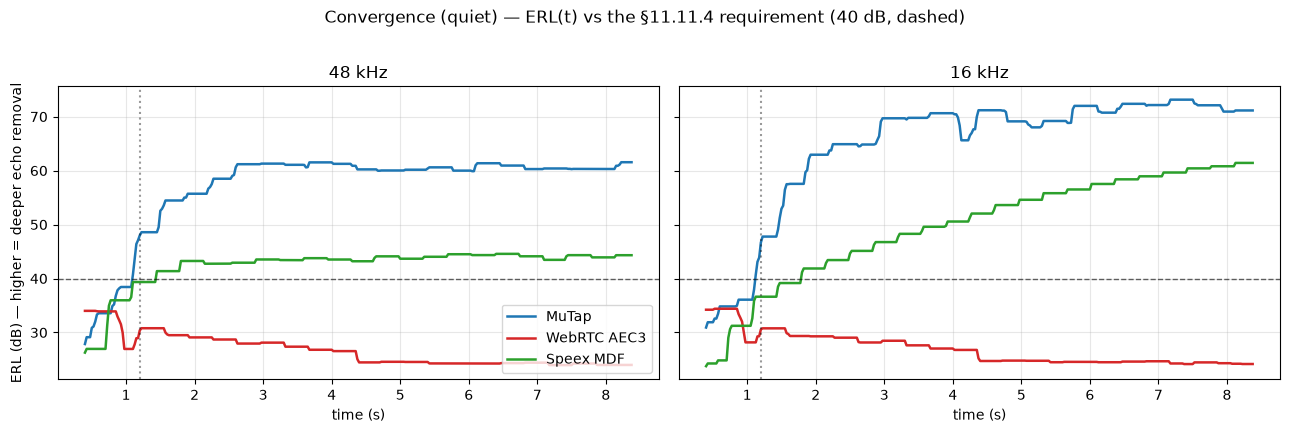

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
for ax, fs in zip(axes, ['48000', '16000']):
    for s in SUBJECTS:
        c = D[fs]['convergence'].get(s)
        if not c: continue
        t, v = trace_xy(c)
        ax.plot(t, v, color=COL[s], label=LBL[s], lw=1.8)
    ax.axhline(40, ls='--', color='k', alpha=0.6, lw=1)
    ax.axvline(1.2, ls=':', color='k', alpha=0.4)
    ax.set_title(f'{int(fs)//1000} kHz'); ax.set_xlabel('time (s)'); ax.grid(alpha=0.3)
axes[0].set_ylabel('ERL (dB) — higher = deeper echo removal'); axes[0].legend(loc='lower right')
fig.suptitle('Convergence (quiet) — ERL(t) vs the §11.11.4 requirement (40 dB, dashed)', y=1.02)
plt.tight_layout(); plt.show()

MuTap climbs past the others to its deep steady floor; AEC3 locks
almost instantly but plateaus far shallower (it optimises for perceived
echo, not ERL depth — see the AECMOS table in the doc); Speex sits
between, converging slowly to a mid depth.

## 2. Re-convergence after an abrupt path change (§11.11.6/7)

Converge on the cabin, then swap to the studio path mid-run (vertical
line). How fast does each canceller recover its echo suppression?

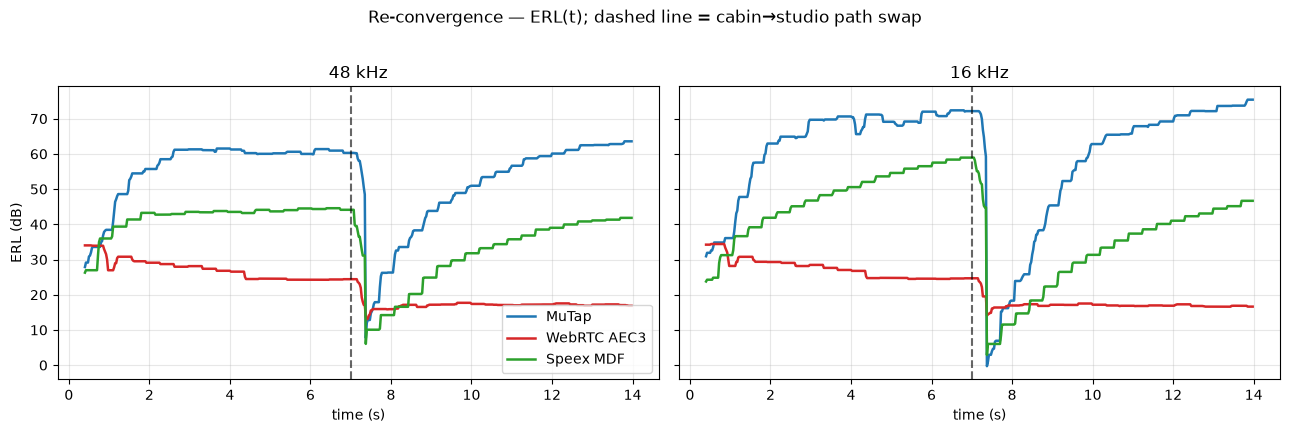

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
for ax, fs in zip(axes, ['48000', '16000']):
    rc = D[fs]['reconvergence']; swap = rc['swap_s']
    for s in SUBJECTS:
        c = rc['curves'].get(s)
        if not c: continue
        t, v = trace_xy(c)
        ax.plot(t, v, color=COL[s], label=LBL[s], lw=1.8)
    ax.axvline(swap, ls='--', color='k', alpha=0.6); ax.set_title(f'{int(fs)//1000} kHz')
    ax.set_xlabel('time (s)'); ax.grid(alpha=0.3)
axes[0].set_ylabel('ERL (dB)'); axes[0].legend(loc='lower right')
fig.suptitle('Re-convergence — ERL(t); dashed line = cabin→studio path swap', y=1.02)
plt.tight_layout(); plt.show()

AEC3's fast delay/filter re-estimation is its home turf; MuTap's
chain recovers more slowly to a much deeper floor (its rescue comparator
is tuned conservative, per docs/itu-compliance.md). The trade is depth
vs agility, made visible.

## 3. Steady-state ERL and double-talk near-end preservation

Left: converged single-talk ERL (depth). Right: near-end level preserved
during double talk — a CSS talker enters mid-run over the echo; 0 dB =
the near end passes untouched, negative = the canceller ducks it. The
orthogonal ITU echo-loss-during-double-talk measurement needs the full
comb analysis and stays in the compliance suite; this is the duplex
companion.

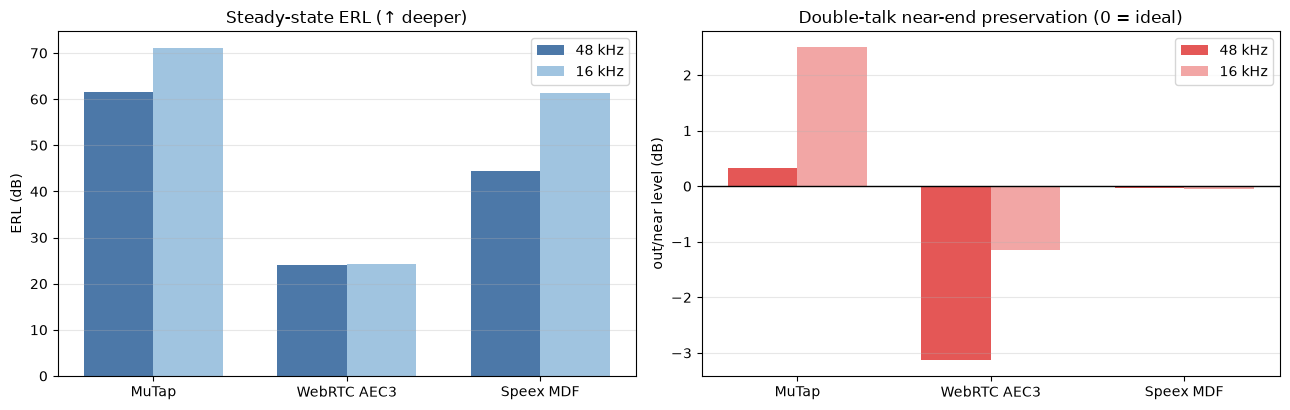

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))
x = np.arange(len(SUBJECTS)); w = 0.36
for i, fs in enumerate(['48000', '16000']):
    ax1.bar(x + i*w, [D[fs]['steady_erl'].get(s, 0) for s in SUBJECTS], w,
            label=f'{int(fs)//1000} kHz', color=['#4c78a8', '#a0c4e0'][i])
    ax2.bar(x + i*w, [D[fs]['doubletalk_near_keep'].get(s, 0) for s in SUBJECTS], w,
            label=f'{int(fs)//1000} kHz', color=['#e45756', '#f2a6a5'][i])
for ax, ttl, yl in ((ax1, 'Steady-state ERL (↑ deeper)', 'ERL (dB)'),
                    (ax2, 'Double-talk near-end preservation (0 = ideal)', 'out/near level (dB)')):
    ax.set_xticks(x + w/2); ax.set_xticklabels([LBL[s] for s in SUBJECTS])
    ax.set_title(ttl); ax.set_ylabel(yl); ax.grid(axis='y', alpha=0.3); ax.legend()
ax2.axhline(0, color='k', lw=1)
plt.tight_layout(); plt.show()

**Reading it together.** MuTap trades convergence speed for
steady-state depth and near-perfect double-talk transparency; AEC3 trades
depth for the fastest lock and re-lock while ducking the near end a little
more; Speex is the classical middle. The full numeric matrix, the
reciprocal AECMOS scoring, and every caveat are in
[`docs/aec-comparison.md`](../docs/aec-comparison.md).